# Install and import packages

In [1]:
!pip install --upgrade seaborn
!pip install plotly

  Using cached plotly-6.5.0-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.5.0-py3-none-any.whl (9.9 MB)


In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Utils and Global variables

In [3]:
# Load original dataset
data_original = pd.read_csv('./datasets/vehicle_8_99632e+18.csv')

In [4]:
# Load synthetic dataset
epoch = 1200
synthetic_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin1/windows_size_20/Generated_data/epoch_{epoch}/EV_generated_data_{epoch}.csv')

In [5]:
# Set SAVE equals to True, in order to Save cleaned data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin1/windows_size_20/'
    
    file_trip_path_csv = os.path.join(output_dir, f'EV_generated_data__trip_cleaned.csv')
    file_charge_path_csv = os.path.join(output_dir, f'EV_generated_data__charge_cleaned.csv')
    file_cleaned_path_csv = os.path.join(output_dir, f'EV_generated_data_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

In [6]:
# Set REASSIGN_CHARGE_MODE to True, in order to have a similar behavior with the original dataset for charge_mode feature
REASSIGN_CHARGE_MODE = True

In [7]:
# ===============================
# Threshold Configuration
# ===============================

# --- Discharge thresholds ---
MAX_DISCHARGE_PER_KM = 0.9    # Maximum allowable battery discharge per km
MIN_DISCHARGE_PER_KM = -1.0   # Minimum (negative) discharge per km

# --- Distance per discharge thresholds ---
MAX_KM_PER_DISCHARGE = 20     # Max km possible per discharge unit
MIN_KM_PER_DISCHARGE = -10    # Min km per discharge unit (negative edge case)

# --- Charging thresholds ---
MAX_CHARGE_PER_MIN = 1.10     # Maximum acceptable charge per minute
MIN_CHARGE_PER_MIN = 0.005    # Minimum acceptable charge per minute


# --- Speed threshold ---
SPEED_THRESHOLD = 130         # Max speed before flagging over-speed conditions


# Original dataset

## Trip data original

In [8]:
#trip_ data
trip_data_original = data_original[data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1145 entries, 0 to 1144
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          1145 non-null   float64
 1   timestamp    1145 non-null   object 
 2   end_time     1145 non-null   object 
 3   odo          1145 non-null   float64
 4   end_odo      1145 non-null   float64
 5   soc          1145 non-null   float64
 6   end_soc      1145 non-null   float64
 7   event        1145 non-null   object 
 8   charge_mode  1145 non-null   object 
dtypes: float64(5), object(4)
memory usage: 80.6+ KB


In [9]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 1145
Statistics on driven km:
 count    1145.000000
mean       25.680523
std        40.549802
min         0.000000
25%         1.332590
50%         5.328130
75%        25.343750
max       257.906250
Name: km_driven, dtype: float64

Statistics on discharge:
 count    1145.000000
mean        6.240437
std        10.845429
min        -0.800000
25%         0.000000
50%         1.200000
75%         5.900000
max        86.700000
Name: discharge, dtype: float64


In [10]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

In [11]:
anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 35


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
52,-8.996320e+18,2021-01-11 14:12:00,2021-01-11 14:18:00,5540.781250,5540.812500,74.5,74.1,trip,0,0.031250,0.4,0.078125,12.800000
68,-8.996320e+18,2021-01-14 10:47:00,2021-01-14 10:52:00,6163.546875,6163.593750,85.8,85.4,trip,0,0.046875,0.4,0.117188,8.533333
92,-8.996320e+18,2021-01-17 14:20:00,2021-01-17 15:14:00,6563.365008,6569.703125,92.5,73.7,trip,0,6.338117,18.8,0.337134,2.966181
96,-8.996320e+18,2021-01-17 20:26:00,2021-01-17 20:34:00,6589.171875,6589.281250,67.8,67.4,trip,0,0.109375,0.4,0.273438,3.657143
100,-8.996320e+18,2021-01-19 09:46:00,2021-01-19 10:59:00,6766.881646,6774.593750,78.0,60.3,trip,0,7.712104,17.7,0.435712,2.295094
129,-8.996320e+18,2021-01-24 14:29:00,2021-01-24 15:23:00,7619.759321,7631.140625,78.8,59.2,trip,0,11.381304,19.6,0.580679,1.722123
165,-8.996320e+18,2021-02-02 17:09:00,2021-02-02 17:13:00,8665.969882,8666.078125,100.0,99.6,trip,0,0.108243,0.4,0.270608,3.695389
174,-8.996320e+18,2021-02-04 10:54:00,2021-02-04 13:26:00,8932.078125,8932.109375,49.0,48.2,trip,0,0.031250,0.8,0.039063,25.600000
190,-8.996320e+18,2021-02-07 15:15:00,2021-02-07 19:40:00,9326.046875,9327.125000,40.7,38.4,trip,0,1.078125,2.3,0.468750,2.133333
213,-8.996320e+18,2021-02-15 12:05:00,2021-02-15 13:08:00,10210.187500,10210.218750,83.1,82.7,trip,0,0.031250,0.4,0.078125,12.800000


In [12]:
anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 1


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
42,-8.996320e+18,2021-01-08 11:13:00,2021-01-08 13:23:00,5201.6875,5201.765625,40.0,40.3,trip,0,0.078125,-0.3,-0.260417,-3.84


In [13]:
# Identify anomalous records with high km per percentage of battery discharge 
anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [14]:
# Identify anomalous records with low km per percentage of battery discharge 
anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [15]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     1109 non-null   float64
 1   timestamp               1109 non-null   object 
 2   end_time                1109 non-null   object 
 3   odo                     1109 non-null   float64
 4   end_odo                 1109 non-null   float64
 5   soc                     1109 non-null   float64
 6   end_soc                 1109 non-null   float64
 7   event                   1109 non-null   object 
 8   charge_mode             1109 non-null   object 
 9   km_driven               1109 non-null   float64
 10  discharge               1109 non-null   float64
 11  km_per_perc_of_battery  1109 non-null   float64
 12  discharge_per_km        1109 non-null   float64
dtypes: float64(9), object(4)
memory usage: 112.8+ KB


In [16]:
trip_data_original['discharge_per_km'].describe()

count    1109.000000
mean        0.167521
std         0.148489
min        -0.984615
25%         0.000000
50%         0.196420
75%         0.261642
max         0.827209
Name: discharge_per_km, dtype: float64

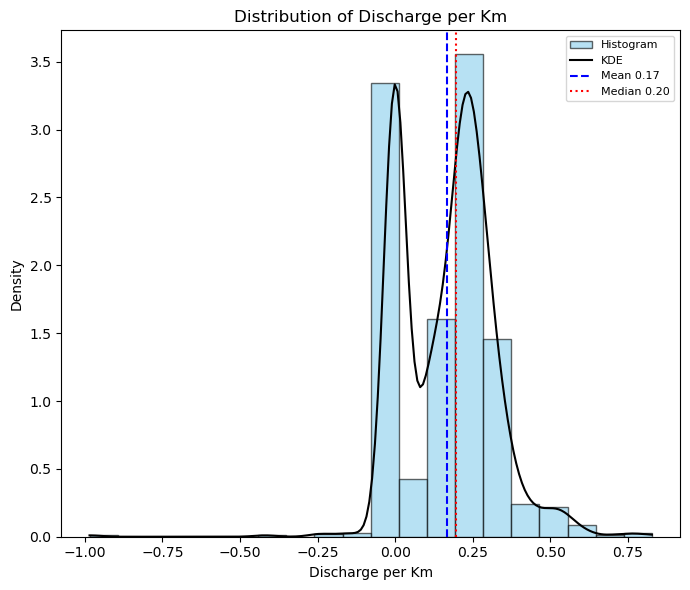

In [17]:
# Function that plot histogram and density of feature values provided
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20, density=True):
    """Plots histogram + KDE + mean & median, using DENSITY (not frequency)."""
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Histogram as DENSITY
    counts, bin_edges, _ = ax.hist(
        y, bins=bins, density=density, alpha=0.6,
        color=color, edgecolor='black', label='Histogram'
    )

    # KDE on density scale
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass

    # Mean & median lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'Mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'Median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

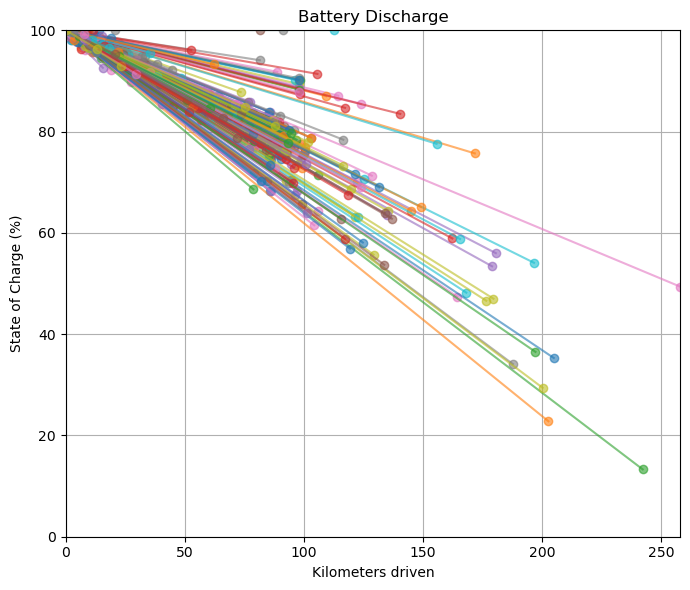

In [18]:
#visualize delta_soc
trip_data_original['delta_soc'] = trip_data_original['end_soc'] - trip_data_original['soc']
trip_data_original['soc'] = 100
trip_data_original['end_soc'] = trip_data_original['soc'] + trip_data_original['delta_soc'] 



# Max km for x-axis scaling
max_km_driven = trip_data_original['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data_original.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data_original.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


## Charge data original

In [19]:
charge_data_original = data_original[data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          224 non-null    float64
 1   timestamp    224 non-null    object 
 2   end_time     224 non-null    object 
 3   odo          224 non-null    float64
 4   end_odo      224 non-null    float64
 5   soc          224 non-null    float64
 6   end_soc      224 non-null    float64
 7   event        224 non-null    object 
 8   charge_mode  224 non-null    object 
dtypes: float64(5), object(4)
memory usage: 15.9+ KB


In [20]:
# Count number of entries for each charge_mode
counts = charge_data_original['charge_mode'].value_counts()
print(counts)

charge_mode
240           99
DCCharging    75
120           50
Name: count, dtype: int64


In [21]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['charge'] = charge_data_original['end_soc'] - charge_data_original['soc']
charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\nStatistics on Charge:\n", charge_data_original['charge'].describe())

Number of rows after removing duplicates: 224

Statistics on Charge:
 count    224.000000
mean      27.886607
std       20.374474
min        0.300000
25%        9.000000
50%       24.700000
75%       44.325000
max       90.600000
Name: charge, dtype: float64


In [22]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

In [23]:
anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 9


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,charge,discharge,duration_minutes,min_per_perc_of_battery,charge_per_min
16,-8.996320e+18,2021-01-15 14:05:00,2021-01-15 14:34:00,6380.484375,6380.484375,30.5,65.4,charge,DCCharging,34.9,-34.9,29.0,0.830946,1.203448
105,-8.996320e+18,2021-04-15 13:54:00,2021-04-15 14:14:00,19160.515630,19160.515630,24.3,53.3,charge,DCCharging,29.0,-29.0,20.0,0.689655,1.450000
112,-8.996320e+18,2021-04-18 14:40:00,2021-04-18 14:55:00,19712.149030,19712.149030,39.2,58.8,charge,DCCharging,19.6,-19.6,15.0,0.765306,1.306667
119,-8.996320e+18,2021-04-25 14:48:00,2021-04-25 15:19:00,20790.796880,20790.796880,12.9,52.1,charge,DCCharging,39.2,-39.2,31.0,0.790816,1.264516
120,-8.996320e+18,2021-04-26 23:32:00,2021-04-27 00:09:00,20932.529370,20932.529370,11.3,57.2,charge,DCCharging,45.9,-45.9,37.0,0.806100,1.240541
125,-8.996320e+18,2021-05-02 10:04:00,2021-05-02 10:17:00,21604.906250,21604.906250,18.0,32.5,charge,DCCharging,14.5,-14.5,13.0,0.896552,1.115385
157,-8.996320e+18,2021-05-25 20:01:00,2021-05-25 20:35:00,26702.984380,26703.000000,23.5,62.7,charge,DCCharging,39.2,-39.2,34.0,0.867347,1.152941
199,-8.996320e+18,2021-06-30 13:52:00,2021-06-30 14:04:00,34227.500000,34227.500000,21.5,36.0,charge,DCCharging,14.5,-14.5,12.0,0.827586,1.208333
213,-8.996320e+18,2021-07-25 21:05:00,2021-07-25 21:49:00,38327.546880,38327.546880,19.6,76.0,charge,DCCharging,56.4,-56.4,44.0,0.780142,1.281818


In [24]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      215 non-null    float64       
 1   timestamp                215 non-null    datetime64[ns]
 2   end_time                 215 non-null    datetime64[ns]
 3   odo                      215 non-null    float64       
 4   end_odo                  215 non-null    float64       
 5   soc                      215 non-null    float64       
 6   end_soc                  215 non-null    float64       
 7   event                    215 non-null    object        
 8   charge_mode              215 non-null    object        
 9   charge                   215 non-null    float64       
 10  discharge                215 non-null    float64       
 11  duration_minutes         215 non-null    float64       
 12  min_per_perc_of_battery  215 non-nul

In [25]:
charge_data_original['charge_per_min'].describe()

count    215.000000
mean       0.268711
std        0.328554
min        0.005128
25%        0.032555
50%        0.103226
75%        0.466356
max        1.084375
Name: charge_per_min, dtype: float64

In [26]:
# Print max charge_data_original['charge_per_min'] 
max_charge_mode_per_minute = charge_data_original.groupby("charge_mode")["charge_per_min"].max()
print(max_charge_mode_per_minute)

charge_mode
120           0.145294
240           0.400000
DCCharging    1.084375
Name: charge_per_min, dtype: float64


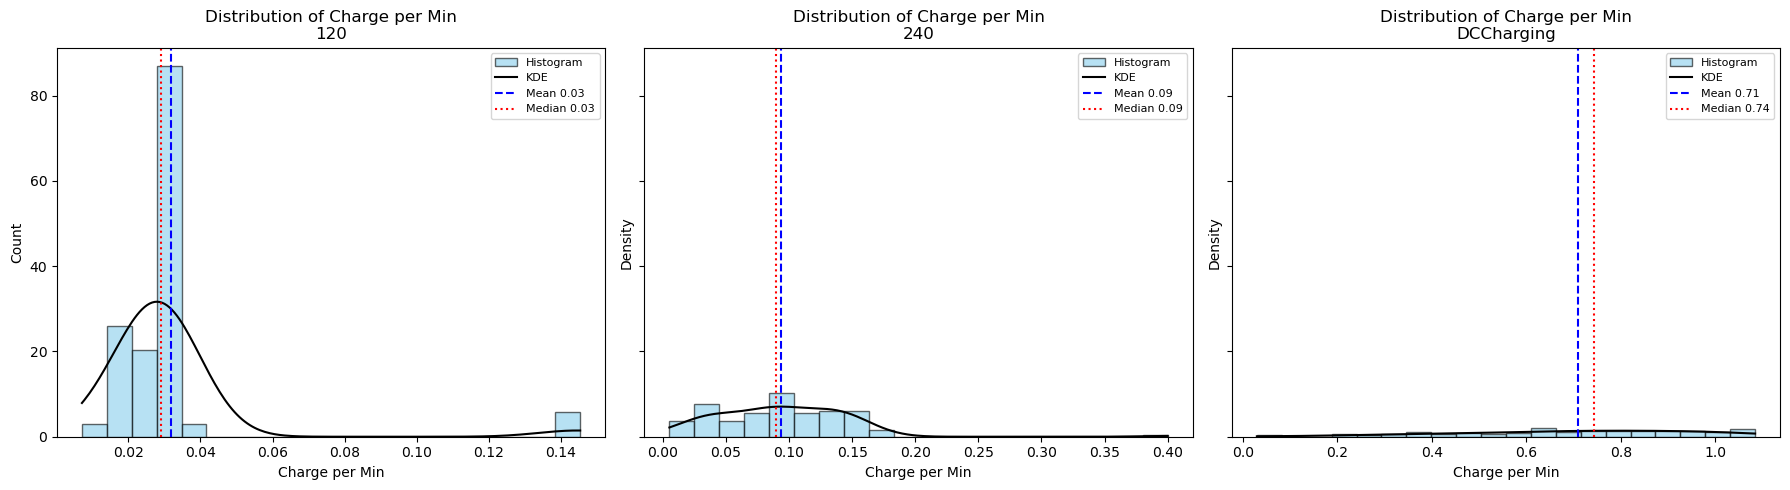

In [27]:
# --- Distribution of Charge per min ---

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate(['120', '240', 'DCCharging']):
    data_mode = charge_data_original.loc[charge_data_original['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='skyblue',
                       title=f"Distribution of Charge per Min\n{mode}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()

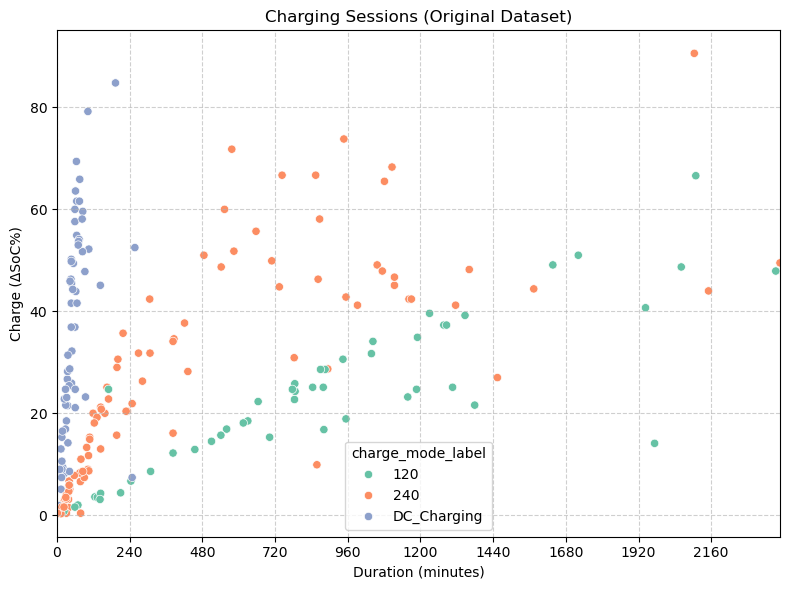

In [28]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
import matplotlib.ticker as mticker

# Mapping of charge_mode
charge_mode_map = {
    '120': "120",
    '240': "240",
    'DCCharging': "DC_Charging"
}

charge_data_original = charge_data_original.copy()
charge_data_original["charge_mode_label"] = charge_data_original["charge_mode"].map(charge_mode_map)

# Define consistent color palette (matching Set2)
fixed_palette = {
    "120": "#66c2a5",       # greenish
    "240": "#fc8d62",       # orange
    "DC_Charging": "#8da0cb" # blue
}

# Define desired order for hues
hue_order = ["120", "240", "DC_Charging"]

# Compute derived features
max_duration = charge_data_original["duration_minutes"].max()
charge_data_original['charge'] = -charge_data_original['discharge']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data_original,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    hue_order=hue_order,     # ← Force order
    palette=fixed_palette,   # ← Consistent colors
    legend="auto"
)

plt.title("Charging Sessions (Original Dataset)")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (ΔSoC%)")
plt.grid(True)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(240))
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Post-processing generated data event-level

## Post-process trip data

### Data Inspection and Cleaning

In [29]:
##### Load trip data
trip_data = synthetic_data.copy()

# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23417 entries, 0 to 23416
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             23417 non-null  int64  
 1   charge_mode       23417 non-null  int64  
 2   duration_minutes  23417 non-null  float64
 3   km_driven         23417 non-null  float64
 4   charge            23417 non-null  float64
 5   id                23417 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.1 MB


In [30]:
trip_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,0,0,176.450850,22.648247,-6.307427,0
1,0,0,89.094606,6.192609,-0.072401,1
2,0,0,66.444884,6.667766,-0.004132,2
3,0,0,67.073304,7.797074,-0.112041,3
4,0,0,127.710209,67.345254,-14.786442,4
5,0,0,97.236197,4.312277,2.871764,5
6,0,0,86.333902,3.803671,1.034608,6
7,0,0,75.332693,15.817045,-3.196548,7
8,0,0,58.974738,5.829426,0.814193,8
9,0,0,64.448008,8.546839,-0.385216,9


### Data description

In [31]:
# Remove duplicates
init_len = len(trip_data)
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(trip_data)}")

Number of duplicates removed: 0


In [32]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
print(f"\nNumber of records with missing values: {length}\n")
records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

Number of records with missing values: 0



,event,charge_mode,duration_minutes,km_driven,charge,id


In [33]:
# main statistics of the dataset
trip_data['delta_soc'] = trip_data['charge']
print("Statistics of the dataset:")
trip_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,23417.0,25.167985,30.287165,2.208562,6.128029,9.120149,33.452298,193.417113
delta_soc,23417.0,-4.838034,7.644888,-52.318533,-9.197162,-1.024447,0.428867,14.501932


In [34]:
# Add discharge
trip_data['discharge'] = - trip_data['charge']


# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['km_driven']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print('Statistics before post-processing\n')
print("Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data['discharge'].describe())
print("\nStatistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\nStatistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\nStatistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics before post-processing

Statistics on driven km:
 count    23417.000000
mean        25.167985
std         30.287165
min          2.208562
25%          6.128029
50%          9.120149
75%         33.452298
max        193.417113
Name: km_driven, dtype: float64

Statistics on discharge:
 count    23417.000000
mean         4.838034
std          7.644888
min        -14.501932
25%         -0.428867
50%          1.024447
75%          9.197162
max         52.318533
Name: discharge, dtype: float64

Statistics on average speed:
 count    23417.000000
mean        12.615852
std         11.209063
min          0.630165
25%          5.393007
50%          7.024702
75%         17.301673
max         52.375967
Name: avg_speed, dtype: float64
99th percentile of average speed: 43.35 km/h

Statistics on km per percentage of battery:
 count    23417.000000
mean         1.497493
std        384.896127
min     -32100.113781
25%         -6.406135
50%          3.834415
75%          4.983959
max      272

### Identify and remove anomalous records

In [35]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [36]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [37]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [38]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [39]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
stationary_records.head(length)

Number of stationary records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [40]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [41]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['charge'] > 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 2180


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
5,0,0,97.236197,4.312277,2.871764,5,2.871764,-2.871764,2.660909,-1.501613,-0.665951
6,0,0,86.333902,3.803671,1.034608,6,1.034608,-1.034608,2.643461,-3.676436,-0.272003
29,0,0,111.664313,3.826528,3.283469,31,3.283469,-3.283469,2.056088,-1.165392,-0.858080
31,0,0,133.007379,3.916810,5.441752,33,5.441752,-5.441752,1.766884,-0.719770,-1.389333
33,0,0,115.413941,5.554888,3.541389,35,3.541389,-3.541389,2.887808,-1.568562,-0.637527
...,...,...,...,...,...,...,...,...,...,...,...
23367,0,0,84.921672,4.875434,2.823606,26944,2.823606,-2.823606,3.444657,-1.726669,-0.579150
23379,0,0,121.967940,4.961151,3.928290,26958,3.928290,-3.928290,2.440552,-1.262929,-0.791810
23393,0,0,124.430812,3.379212,1.925224,26973,1.925224,-1.925224,1.629442,-1.755231,-0.569726
23401,0,0,67.809167,5.256809,1.282478,26983,1.282478,-1.282478,4.651415,-4.098945,-0.243965


In [42]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [43]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['km_driven'] < 0)]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
anomalous_movement_records.head(length)

Number of anomalous movement records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [44]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [45]:
# Identify records with high average speed 
anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]
length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [46]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [47]:
# Identify anomalous records with high discharge per km
anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 59


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
117,0,0,102.519401,2.906832,-2.696607,150,-2.696607,2.696607,1.701238,1.077959,0.927679
233,0,0,102.207319,2.974806,-3.267268,295,-3.267268,3.267268,1.746337,0.910487,1.098313
616,0,0,130.335798,8.621152,-8.172604,788,-8.172604,8.172604,3.968742,1.054884,0.947971
720,0,0,119.012867,2.470394,-2.340727,926,-2.340727,2.340727,1.245442,1.055396,0.947512
1443,0,1,122.362412,5.492342,-5.813594,1833,-5.813594,5.813594,2.693152,0.944741,1.058491
2333,0,0,109.831193,3.065374,-3.026706,2956,-3.026706,3.026706,1.674592,1.012776,0.987385
2454,0,0,108.828348,3.011501,-3.174984,3111,-3.174984,3.174984,1.660321,0.948509,1.054286
2728,0,0,121.109437,2.374732,-2.513449,3469,-2.513449,2.513449,1.176489,0.944810,1.058414
2823,0,0,102.117935,2.773876,-2.763549,3589,-2.763549,2.763549,1.629808,1.003737,0.996277
3045,0,0,114.403773,2.849713,-3.330369,3872,-3.330369,3.330369,1.494555,0.855675,1.168668


In [48]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [49]:
# Identify anomalous records with low discharge per km
anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [50]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [51]:
# Identify anomalous records with high km per percentage of battery discharge 
anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 1594


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
3928,0,0,67.724424,7.353678,-0.000270,5004,-0.000270,0.000270,6.514942,27280.522463,0.000037
3168,0,0,59.629470,6.467846,-0.000344,4036,-0.000344,0.000344,6.508037,18827.430152,0.000053
4918,0,0,89.586007,8.561297,-0.000687,6257,-0.000687,0.000687,5.733907,12462.040182,0.000080
2955,0,0,59.136504,6.260522,-0.000745,3765,-0.000745,0.000745,6.351936,8402.105209,0.000119
678,0,0,94.207027,5.022714,-0.000655,881,-0.000655,0.000655,3.198942,7664.914920,0.000130
...,...,...,...,...,...,...,...,...,...,...,...
14552,0,0,73.713853,11.625301,-0.579586,18563,-0.579586,0.579586,9.462510,20.057933,0.049856
18263,0,0,66.676213,8.739730,-0.435842,23308,-0.435842,0.435842,7.864631,20.052540,0.049869
15672,0,0,83.177019,9.944036,-0.496248,20002,-0.496248,0.496248,7.173161,20.038452,0.049904
21,0,0,67.540536,8.379305,-0.418336,25,-0.418336,0.418336,7.443801,20.030092,0.049925


In [52]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [53]:
# Identify anomalous records with low km per percentage of battery discharge 
anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 3859


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
1169,0,0,61.039499,5.803056,0.580241,1623,0.580241,-0.580241,5.704230,-10.001109,-0.099989
391,0,0,61.691878,5.555379,0.555470,545,0.555470,-0.555470,5.403024,-10.001221,-0.099988
5829,0,0,70.748669,4.997352,0.499598,8044,0.499598,-0.499598,4.238117,-10.002755,-0.099972
19573,0,0,58.932529,6.046513,0.604458,26987,0.604458,-0.604458,6.156036,-10.003204,-0.099968
3098,0,0,61.755389,6.182793,0.618069,4286,0.618069,-0.618069,6.007048,-10.003401,-0.099966
...,...,...,...,...,...,...,...,...,...,...,...
6153,0,0,64.089455,7.767637,0.001041,8475,0.001041,-0.001041,7.271995,-7462.694396,-0.000134
14439,0,0,67.497907,8.626836,0.000761,19954,0.000761,-0.000761,7.668537,-11338.973870,-0.000088
18845,0,0,84.059645,7.904891,0.000660,26001,0.000660,-0.000660,5.642344,-11969.531876,-0.000084
12868,0,0,80.762643,5.716280,0.000333,17809,0.000333,-0.000333,4.246726,-17175.668004,-0.000058


In [54]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [55]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15725 entries, 0 to 15724
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   15725 non-null  int64  
 1   charge_mode             15725 non-null  int64  
 2   duration_minutes        15725 non-null  float64
 3   km_driven               15725 non-null  float64
 4   charge                  15725 non-null  float64
 5   id                      15725 non-null  int64  
 6   delta_soc               15725 non-null  float64
 7   discharge               15725 non-null  float64
 8   avg_speed               15725 non-null  float64
 9   km_per_perc_of_battery  15725 non-null  float64
 10  discharge_per_km        15725 non-null  float64
dtypes: float64(8), int64(3)
memory usage: 1.3 MB


In [56]:
# Print statistics
print('Statistics after post-processing\n')
print("Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data['discharge'].describe())
print("\nStatistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\nStatistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\nStatistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics after post-processing

Statistics on driven km:
 count    15725.000000
mean        34.299329
std         33.326530
min          2.208562
25%          8.094188
50%         17.899562
75%         56.992581
max        193.417113
Name: km_driven, dtype: float64

Statistics on discharge:
 count    15725.000000
mean         7.581235
std          7.936136
min         -0.999850
25%          0.964448
50%          4.892395
75%         13.505321
max         52.318533
Name: discharge, dtype: float64

Statistics on average speed:
 count    15725.000000
mean        16.244678
std         12.061996
min          0.906027
25%          6.073553
50%         11.286575
75%         25.334871
max         52.375967
Name: avg_speed, dtype: float64
99th percentile of average speed: 44.37 km/h

Statistics on km per percentage of battery:
 count    15725.000000
mean         3.464914
std          5.555074
min         -9.999874
25%          3.171674
50%          4.281545
75%          5.078219
max         1

### Data Visualization and Comparative Analysis

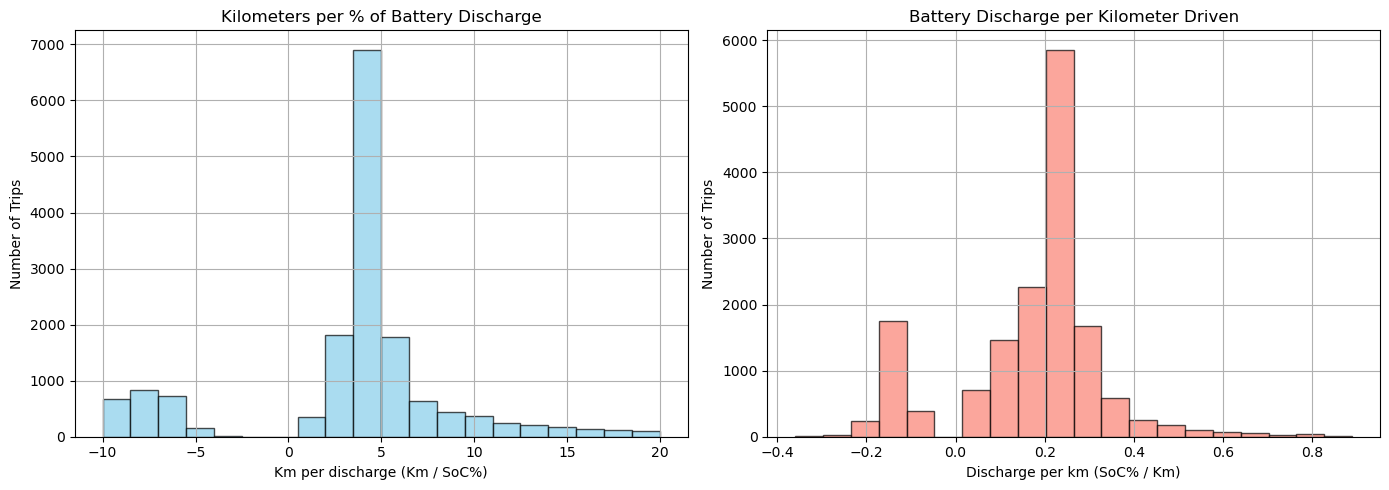

In [57]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [58]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,176.450850,22.648247,-6.307427,0,-6.307427,6.307427,7.701265,3.590727,0.278495
1,0,0,127.710209,67.345254,-14.786442,4,-14.786442,14.786442,31.639720,4.554527,0.219562
2,0,0,75.332693,15.817045,-3.196548,7,-3.196548,3.196548,12.597753,4.948165,0.202095
3,0,0,58.974738,5.829426,0.814193,8,0.814193,-0.814193,5.930769,-7.159755,-0.139670
4,0,0,120.071916,36.500962,-12.587256,10,-12.587256,12.587256,18.239550,2.899835,0.344847


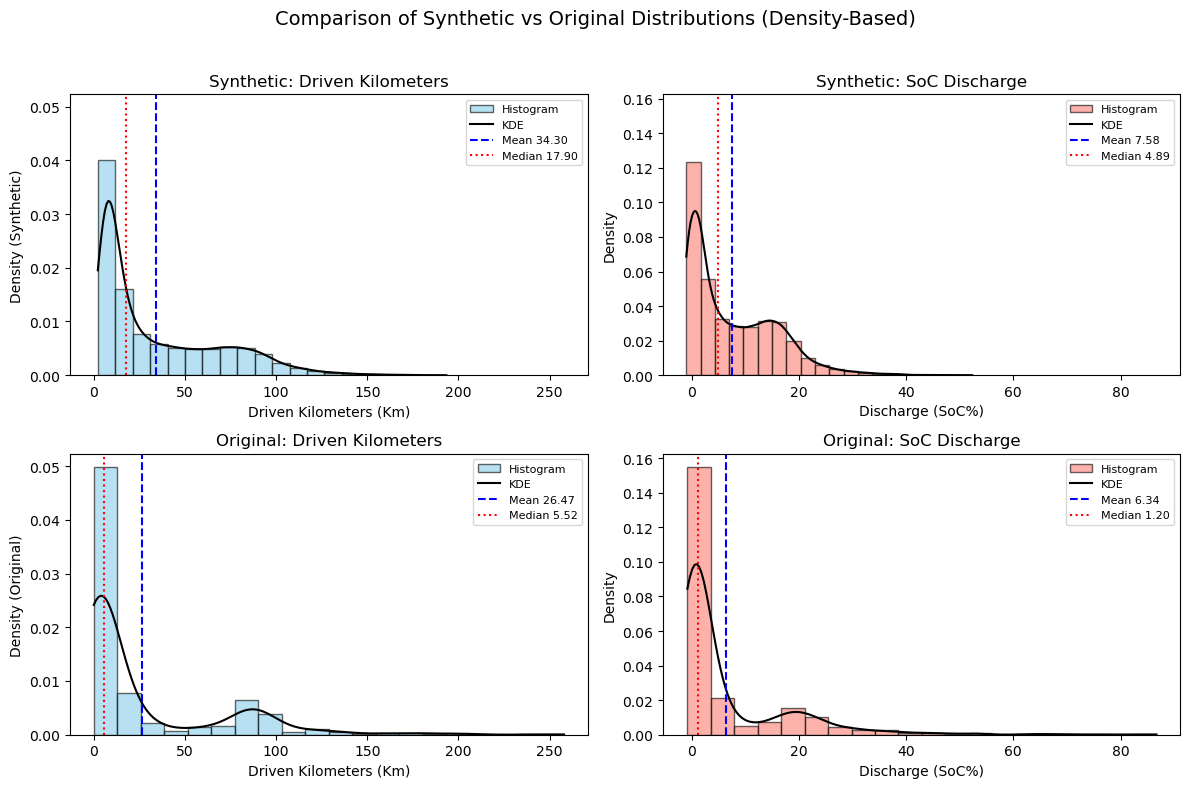

In [59]:
### Visualize comparison between generated and original trip data of main features

# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Discharge', xlabel='Discharge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(trip_data_original.get('km_driven', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data_original.get('discharge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Discharge', xlabel='Discharge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

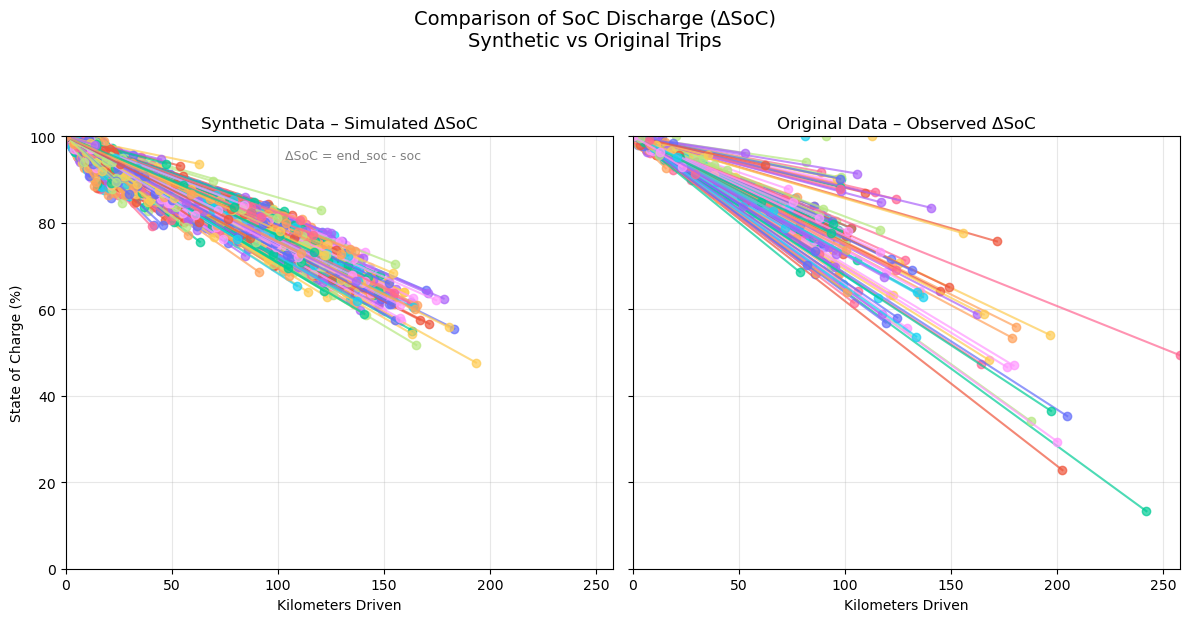

In [60]:
# --- Synthetic data prep ---
trip_data['soc'] = 100
trip_data['end_soc'] = trip_data['soc'] + trip_data['charge']

# --- Shared scales ---
max_km_driven = max(trip_data['km_driven'].max(), trip_data_original['km_driven'].max())

# --- Colors ---
colors = px.colors.qualitative.Plotly

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# ====================================================
# LEFT PANEL – SYNTHETIC
# ====================================================
ax = axes[0]
for i, (_, row) in enumerate(trip_data.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Synthetic Data – Simulated ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.text(max_km_driven * 0.4, 95, "ΔSoC = end_soc - soc", fontsize=9, color='gray')

# ====================================================
# RIGHT PANEL – ORIGINAL
# ====================================================
ax = axes[1]
for i, (_, row) in enumerate(trip_data_original.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Original Data – Observed ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# ====================================================
# SHARED SETTINGS
# ====================================================
# Reverse y-axis for intuitive "battery discharge" visualization
for ax in axes:
    ax.invert_yaxis()

fig.suptitle('Comparison of SoC Discharge (ΔSoC)\nSynthetic vs Original Trips', fontsize=14, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [61]:
trip_data['discharge_per_km'].describe()

count    15725.000000
mean         0.173198
std          0.163804
min         -0.359480
25%          0.111046
50%          0.211172
75%          0.250097
max          0.888875
Name: discharge_per_km, dtype: float64

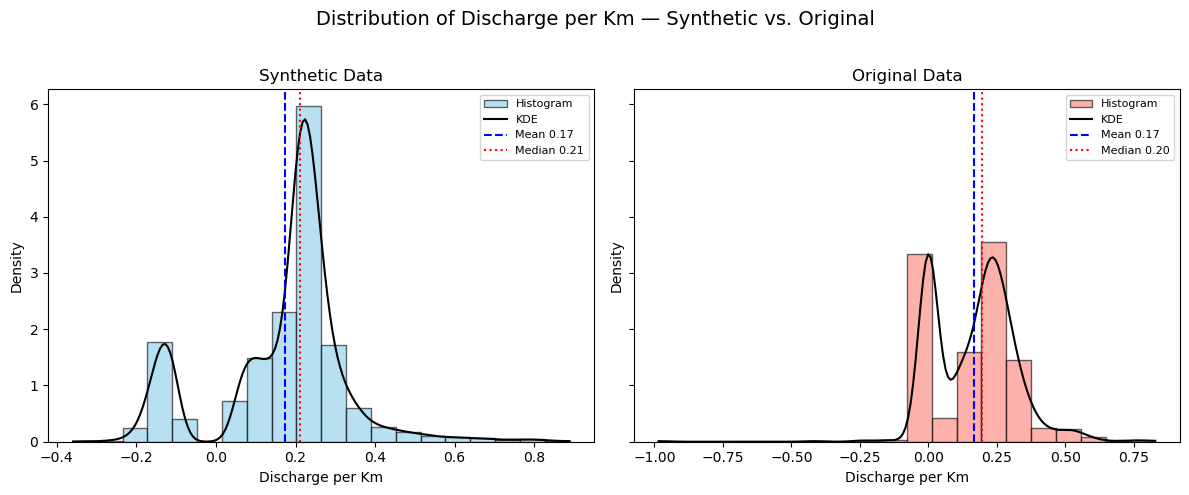

In [62]:
# --- Distribution of Discharge per Km ---
# --- Create side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left panel — synthetic data
plot_hist_with_kde(
    trip_data.get('discharge_per_km', pd.Series(dtype=float)),
    axes[0],
    color='skyblue',
    title='Synthetic Data',
    xlabel='Discharge per Km'
)

# Right panel — original data
plot_hist_with_kde(
    trip_data_original.get('discharge_per_km', pd.Series(dtype=float)),
    axes[1],
    color='salmon',
    title='Original Data',
    xlabel='Discharge per Km',
    density=True
)

# --- Styling ---
fig.suptitle('Distribution of Discharge per Km — Synthetic vs. Original', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Save trip data cleaned

In [63]:
# Save DataFrame
if SAVE:
    trip_data.to_csv(file_trip_path_csv, index=False)

In [64]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km,soc,end_soc
0,0,0,176.450850,22.648247,-6.307427,0,-6.307427,6.307427,7.701265,3.590727,0.278495,100,93.692573
1,0,0,127.710209,67.345254,-14.786442,4,-14.786442,14.786442,31.639720,4.554527,0.219562,100,85.213558
2,0,0,75.332693,15.817045,-3.196548,7,-3.196548,3.196548,12.597753,4.948165,0.202095,100,96.803452
3,0,0,58.974738,5.829426,0.814193,8,0.814193,-0.814193,5.930769,-7.159755,-0.139670,100,100.814193
4,0,0,120.071916,36.500962,-12.587256,10,-12.587256,12.587256,18.239550,2.899835,0.344847,100,87.412744


In [65]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15725 entries, 0 to 15724
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   15725 non-null  int64  
 1   charge_mode             15725 non-null  int64  
 2   duration_minutes        15725 non-null  float64
 3   km_driven               15725 non-null  float64
 4   charge                  15725 non-null  float64
 5   id                      15725 non-null  int64  
 6   delta_soc               15725 non-null  float64
 7   discharge               15725 non-null  float64
 8   avg_speed               15725 non-null  float64
 9   km_per_perc_of_battery  15725 non-null  float64
 10  discharge_per_km        15725 non-null  float64
 11  soc                     15725 non-null  int64  
 12  end_soc                 15725 non-null  float64
dtypes: float64(9), int64(4)
memory usage: 1.6 MB


## Post-process charge data

### Data Inspection and Cleaning

In [66]:
#### Load charge data
charge_data = synthetic_data.copy()

# Add a column id to keep the number of the row
charge_data['id'] = charge_data.index
charge_data = charge_data[charge_data['event'] == 1].reset_index(drop=True)
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3583 entries, 0 to 3582
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             3583 non-null   int64  
 1   charge_mode       3583 non-null   int64  
 2   duration_minutes  3583 non-null   float64
 3   km_driven         3583 non-null   float64
 4   charge            3583 non-null   float64
 5   id                3583 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 168.1 KB


In [67]:
charge_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,1,1,674.604481,4.769321,19.095504,19
1,1,2,670.376902,5.825707,29.133977,20
2,1,3,235.784913,2.128132,30.887551,42
3,1,2,146.485113,2.499009,9.999012,43
4,1,3,163.572543,2.514074,21.189978,46
5,1,1,237.270662,12.714121,-2.012134,59
6,1,2,633.769187,2.580447,41.065668,61
7,1,3,177.570875,6.444258,15.479252,62
8,1,0,130.152200,2.251937,-1.830213,91
9,1,1,384.986282,5.285369,10.645451,99


### Data description

In [68]:
# Remove duplicates
init_len = len(charge_data)
charge_data = charge_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(charge_data)}")

Number of duplicates removed: 0


In [69]:
# Check for missing values and print records with them
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")



records_with_nan = charge_data[charge_data.isna().any(axis=1)]

length = len(records_with_nan)
print(f"\nNumber of records with missing values: {length}\n")
records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

Number of records with missing values: 0



,event,charge_mode,duration_minutes,km_driven,charge,id


In [70]:
# main statistics of the dataset
charge_data['delta_soc'] = charge_data['charge']
print("Statistics of the dataset:")
charge_data[['duration_minutes', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
duration_minutes,3583.0,352.797391,214.685076,111.391012,185.963356,284.824724,453.370601,1442.174163
delta_soc,3583.0,15.545460,12.569267,-20.118911,5.220766,14.212868,25.426228,50.480518


In [71]:
# Add min_per_perc_of_battery and charge_per_min
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / row['charge'] if row['charge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: row['charge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

#Print statistics
print('Statistics before post-processing')
print("\nStatistics on charge:\n", charge_data['charge'].describe())
print("\nStatistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\nStatistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics before post-processing

Statistics on charge:
 count    3583.000000
mean       15.545460
std        12.569267
min       -20.118911
25%         5.220766
50%        14.212868
75%        25.426228
max        50.480518
Name: charge, dtype: float64

Statistics on min_per_perc_of_battery:
 count      3583.000000
mean       -168.434824
std       12672.032930
min     -754077.020856
25%          13.390494
50%          23.747993
75%          33.467927
max       78083.687648
Name: min_per_perc_of_battery, dtype: float64

Statistics on charge_per_min:
 count    3583.000000
mean        0.044201
std         0.043877
min        -0.111660
25%         0.022781
50%         0.037573
75%         0.055892
max         0.276855
Name: charge_per_min, dtype: float64


### Identify and remove anomalous records

In [72]:
# Identify records with negative duration
negative_duration_records = charge_data[(charge_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [73]:
# Remove records with negative duration
charge_data = charge_data.drop(negative_duration_records.index).reset_index(drop=True)

In [74]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = charge_data[(charge_data['charge'] == 0) & (charge_data['km_driven'] == 0) & (charge_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [75]:
# Remove snapshot records
charge_data = charge_data.drop(snapshot_records.index).reset_index(drop=True)

In [76]:
# Identify stationary records (data with no changes in soc, but positive duration)
stationary_records = charge_data[(charge_data['charge'] == 0) & (charge_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
stationary_records.head(length)

Number of stationary rows: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [77]:
# Remove stationary records
charge_data = charge_data.drop(stationary_records.index).reset_index(drop=True)

In [78]:
# Identify records with end_soc [%] < soc [%]   
anomalous_soc_records = charge_data[(charge_data['charge'] < 0)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 346


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
5,1,1,237.270662,12.714121,-2.012134,59,-2.012134,-117.919900,-0.008480
8,1,0,130.152200,2.251937,-1.830213,91,-1.830213,-71.113143,-0.014062
13,1,1,136.054999,5.606638,-1.800248,129,-1.800248,-75.575709,-0.013232
17,1,1,145.064909,7.533118,-2.404357,157,-2.404357,-60.334189,-0.016574
18,1,2,274.765219,32.343044,-7.500807,162,-7.500807,-36.631419,-0.027299
...,...,...,...,...,...,...,...,...,...
3522,1,1,143.773528,2.311600,-0.162899,26555,-0.162899,-882.592931,-0.001133
3535,1,2,281.417377,25.370864,-2.641041,26660,-2.641041,-106.555487,-0.009385
3536,1,1,149.079495,2.083608,-1.437076,26669,-1.437076,-103.738041,-0.009640
3541,1,1,146.358319,2.278244,-2.336595,26695,-2.336595,-62.637429,-0.015965


In [79]:
# Remove anomalous soc records
charge_data = charge_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [80]:
# Identify records with high charge per minute
anomalous_charge_records = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]
length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute > {MAX_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute > 1.1: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [81]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [82]:
# Identify records with low charge per minute
anomalous_charge_records = charge_data[(charge_data['charge_per_min'] < MIN_CHARGE_PER_MIN)]
length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute < {MIN_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute < 0.005: 76


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
71,1,1,172.277072,1.797227,0.595459,672,0.595459,289.318101,0.003456
101,1,1,177.653504,1.848690,0.286559,924,0.286559,619.953944,0.001613
116,1,1,175.900575,1.742274,0.340080,1165,0.340080,517.232408,0.001933
121,1,1,151.768453,2.668523,0.343504,1196,0.343504,441.823971,0.002263
131,1,1,168.204502,3.589822,0.688171,1258,0.688171,244.422455,0.004091
...,...,...,...,...,...,...,...,...,...
2935,1,1,262.796450,10.482847,0.349872,24540,0.349872,751.122758,0.001331
2989,1,1,193.650757,2.981506,0.150265,24961,0.150265,1288.728771,0.000776
3070,1,1,176.360513,2.008143,0.391488,25617,0.391488,450.487763,0.002220
3201,1,1,294.401472,7.163469,0.561060,26719,0.561060,524.723229,0.001906


In [83]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [84]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3161 entries, 0 to 3160
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    3161 non-null   int64  
 1   charge_mode              3161 non-null   int64  
 2   duration_minutes         3161 non-null   float64
 3   km_driven                3161 non-null   float64
 4   charge                   3161 non-null   float64
 5   id                       3161 non-null   int64  
 6   delta_soc                3161 non-null   float64
 7   min_per_perc_of_battery  3161 non-null   float64
 8   charge_per_min           3161 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 222.4 KB


In [85]:
#Print statistics
print('Statistics after post-processing')
print("\nStatistics on charge:\n", charge_data['charge'].describe())
print("\nStatistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\nStatistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics after post-processing

Statistics on charge:
 count    3161.000000
mean       17.959824
std        11.320816
min         0.777771
25%         8.384300
50%        16.534383
75%        26.610044
max        50.480518
Name: charge, dtype: float64

Statistics on min_per_perc_of_battery:
 count    3161.000000
mean       30.901301
std        26.281885
min         3.612002
25%        16.570588
50%        24.865320
75%        34.024566
max       198.907020
Name: min_per_perc_of_battery, dtype: float64

Statistics on charge_per_min:
 count    3161.000000
mean        0.052221
std         0.039857
min         0.005027
25%         0.029391
50%         0.040217
75%         0.060348
max         0.276855
Name: charge_per_min, dtype: float64


### Charge_mode re-assignment

In [86]:
# Print max charge_data_original['charge_per_min'] 
print(charge_data.groupby("charge_mode")["charge_per_min"].max())

charge_mode
0    0.051689
1    0.060587
2    0.131590
3    0.276855
Name: charge_per_min, dtype: float64


In [87]:
if REASSIGN_CHARGE_MODE:

    max_120 = float(max_charge_mode_per_minute.get('120', np.nan))
    max_240 = float(max_charge_mode_per_minute.get('240', np.nan))

    # If one is missing, replace with a safe number
    # - If max_120 missing → treat everything as > max_120
    # - If max_240 missing → treat everything > max_120 as mode 3
    if np.isnan(max_120):
        max_120 = -np.inf   # nothing ≤ max_120
    if np.isnan(max_240):
        max_240 = np.inf    # everything ≤ max_240 if needed

    conditions = [
        charge_data['charge_per_min'] <= max_120,
        (charge_data['charge_per_min'] > max_120) & (charge_data['charge_per_min'] <= max_240)
    ]

    values = [1, 2]

    charge_data['charge_mode'] = np.select(conditions, values, default=3)


### Data Visualization and Comparative Analysis

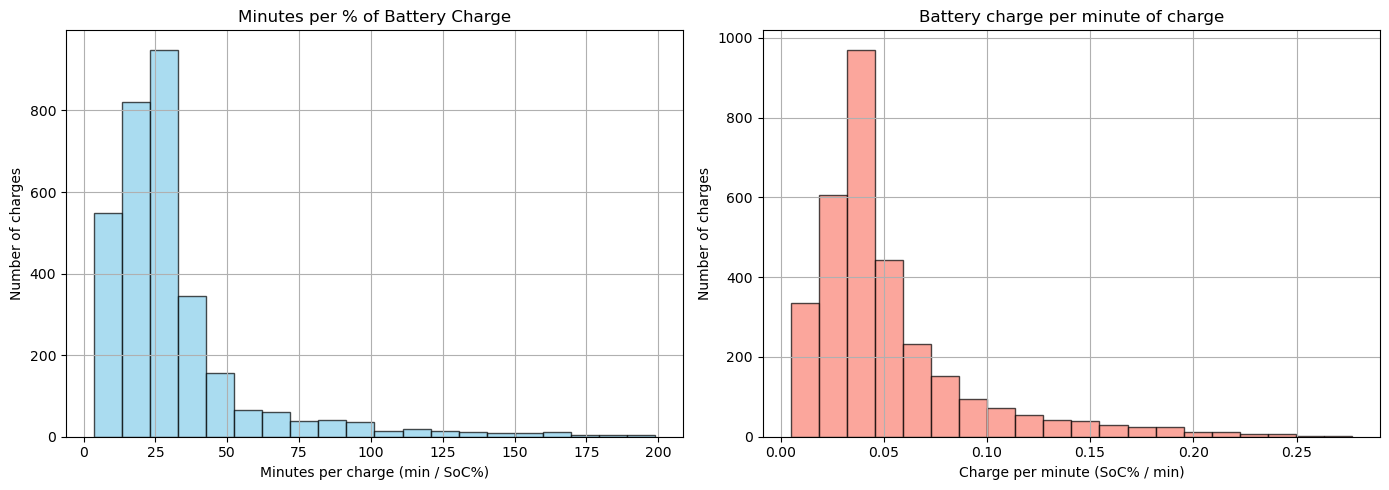

In [88]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [89]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
0,1,1,674.604481,4.769321,19.095504,19,19.095504,35.327922,0.028306
1,1,1,670.376902,5.825707,29.133977,20,29.133977,23.010141,0.043459
2,1,1,235.784913,2.128132,30.887551,42,30.887551,7.633655,0.130999
3,1,1,146.485113,2.499009,9.999012,43,9.999012,14.649959,0.068260
4,1,1,163.572543,2.514074,21.189978,46,21.189978,7.719335,0.129545


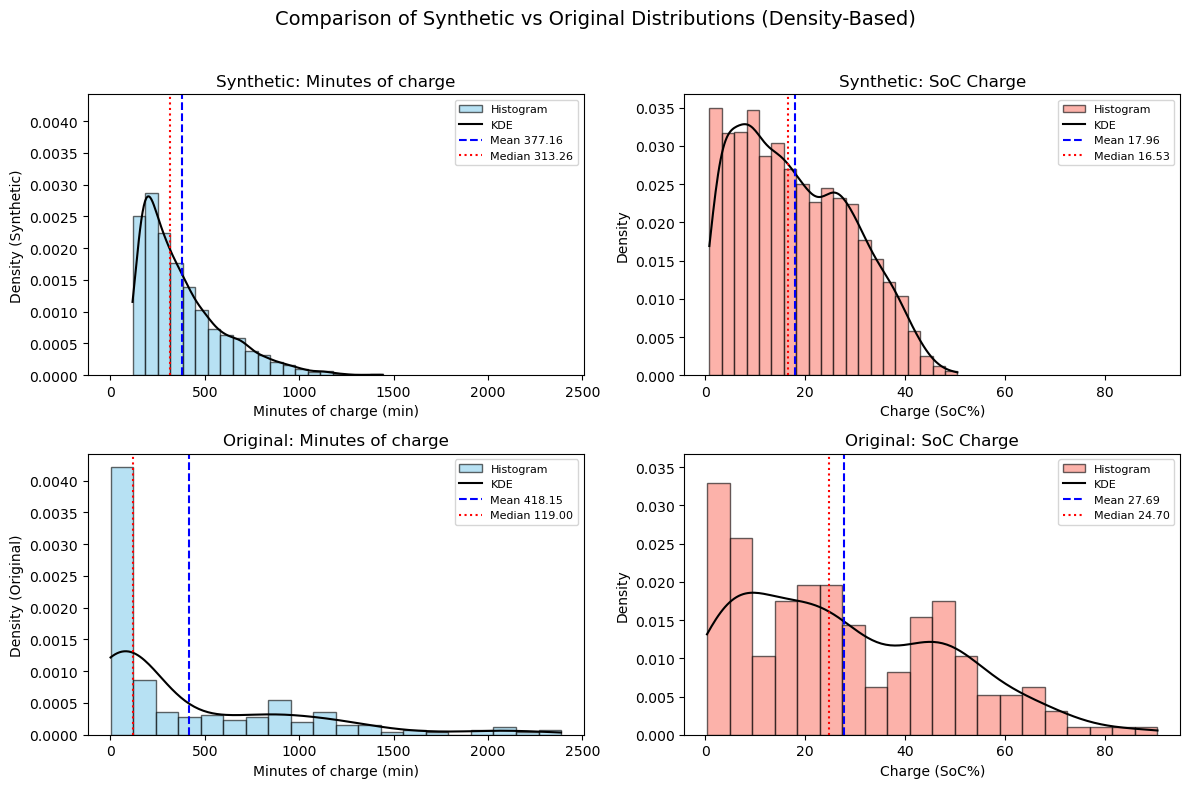

In [90]:
# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data.get('charge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Charge', xlabel='Charge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(charge_data_original.get('duration_minutes', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data_original.get('charge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Charge', xlabel='Charge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

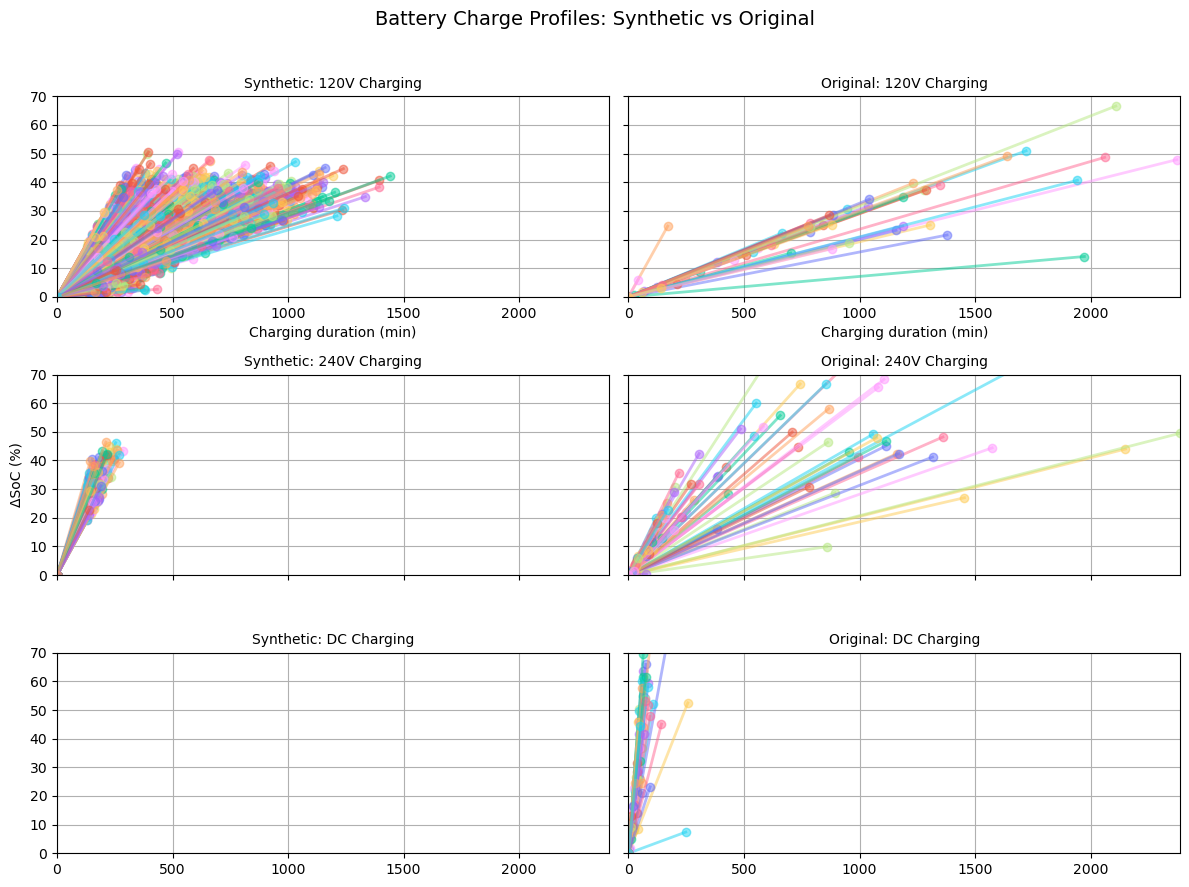

In [91]:
# --- Synthetic data prep ---
charge_data = charge_data.copy()
charge_data['delta_soc'] = charge_data['charge']  # already ΔSoC
charge_data['soc'] = 0
charge_data['end_soc'] = charge_data['delta_soc']

# --- Original data prep ---
charge_data_original = charge_data_original.copy()
charge_data_original['delta_soc'] = (
    charge_data_original['end_soc'] - charge_data_original['soc']
)
charge_data_original['soc'] = 0
charge_data_original['end_soc'] = charge_data_original['delta_soc']

# --- Shared scales ---
max_minutes = max(
    charge_data['duration_minutes'].max(),
    charge_data_original['duration_minutes'].max()
)
max_soc = 70  # y-limit

# --- Colors ---
colors = px.colors.qualitative.Plotly
n_colors = len(colors)

# --- Mode mapping ---
mode_titles = {
    '120': ('Synthetic: 120V Charging', 'Original: 120V Charging'),
    '240': ('Synthetic: 240V Charging', 'Original: 240V Charging'),
    'DC':  ('Synthetic: DC Charging', 'Original: DC Charging')
}

# --- Figure setup ---
fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 9),
    sharex=True, sharey=True
)

# --- Loop through modes ---
for i, (key, (title_syn, title_orig)) in enumerate(mode_titles.items()):

    # --- Filter synthetic (numeric codes) ---
    if key == 'DC':
        syn = charge_data[charge_data['charge_mode'] == 3]
    elif key == '120':
        syn = charge_data[charge_data['charge_mode'] == 1]
    elif key == '240':
        syn = charge_data[charge_data['charge_mode'] == 2]

    # --- Filter original (string-based modes) ---
    if key == 'DC':
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
        ]
    else:
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains(key, case=False, na=False)
        ]

    # --- LEFT: Synthetic ---
    ax_syn = axes[i, 0]
    for j, (_, row) in enumerate(syn.iterrows()):
        ax_syn.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_syn.set_title(title_syn, fontsize=10)
    ax_syn.grid(True)
    ax_syn.set_xlim(0, max_minutes)
    ax_syn.set_ylim(0, max_soc)
    if i == 1:
        ax_syn.set_ylabel("ΔSoC (%)")

    # --- RIGHT: Original ---
    ax_orig = axes[i, 1]
    for j, (_, row) in enumerate(orig.iterrows()):
        ax_orig.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_orig.set_title(title_orig, fontsize=10)
    ax_orig.grid(True)
    ax_orig.set_xlim(0, max_minutes)
    ax_orig.set_ylim(0, max_soc)

# --- Shared ----
for ax in axes[0, :]:
    ax.set_xlabel("Charging duration (min)")
    ax.tick_params(labelbottom=True)

fig.suptitle("Battery Charge Profiles: Synthetic vs Original", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [92]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min,soc,end_soc
0,1,1,674.604481,4.769321,19.095504,19,19.095504,35.327922,0.028306,0,19.095504
1,1,1,670.376902,5.825707,29.133977,20,29.133977,23.010141,0.043459,0,29.133977
2,1,1,235.784913,2.128132,30.887551,42,30.887551,7.633655,0.130999,0,30.887551
3,1,1,146.485113,2.499009,9.999012,43,9.999012,14.649959,0.068260,0,9.999012
4,1,1,163.572543,2.514074,21.189978,46,21.189978,7.719335,0.129545,0,21.189978


In [93]:
charge_data['charge_per_min'].describe()

count    3161.000000
mean        0.052221
std         0.039857
min         0.005027
25%         0.029391
50%         0.040217
75%         0.060348
max         0.276855
Name: charge_per_min, dtype: float64

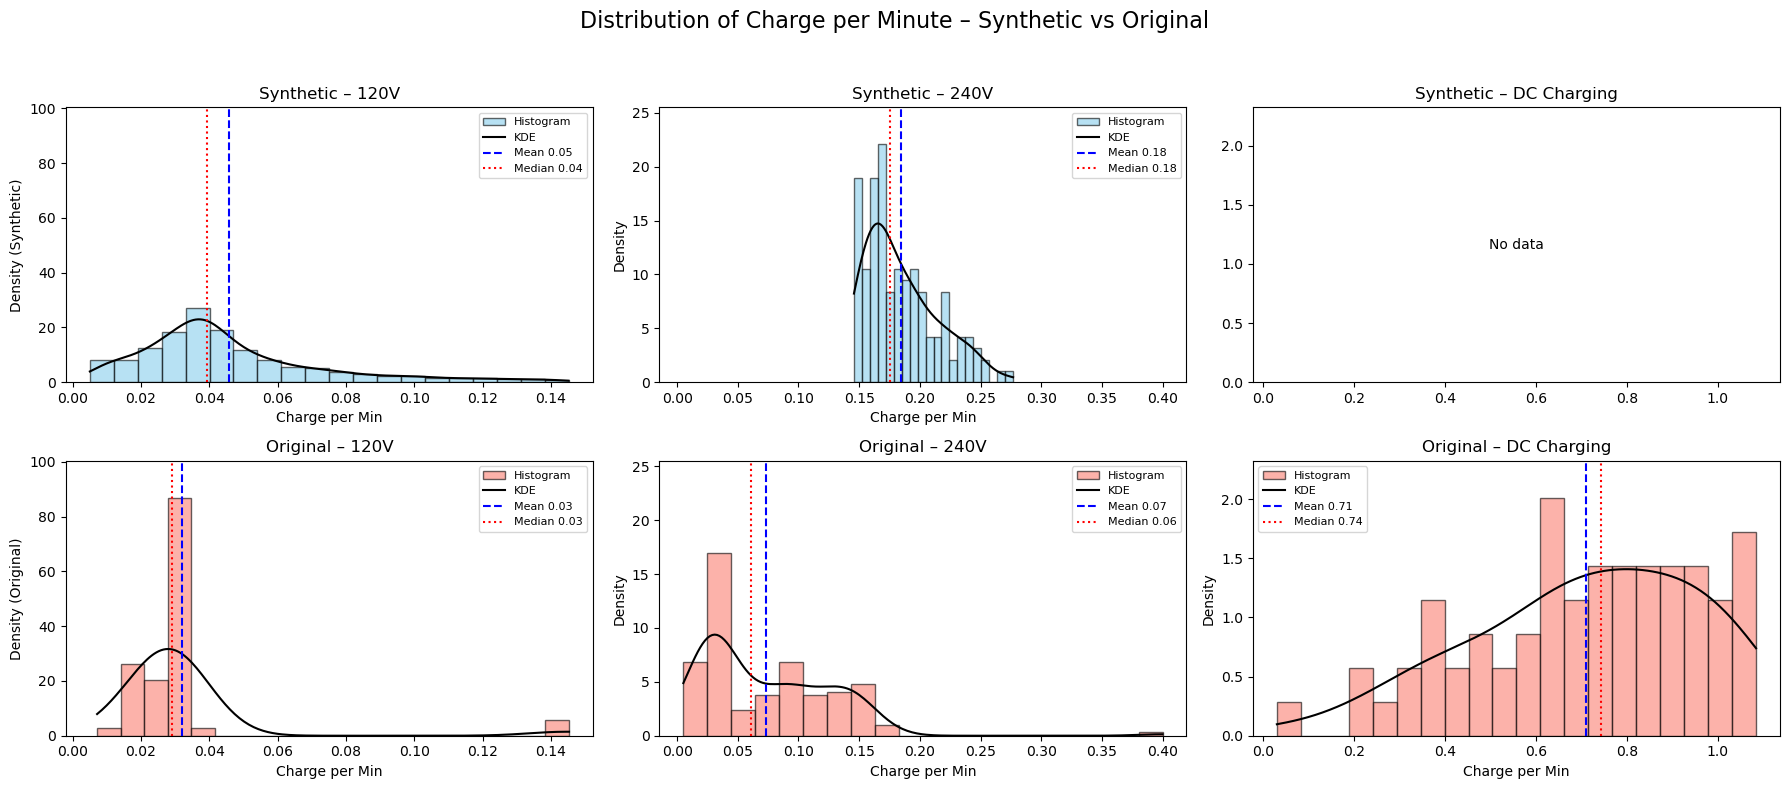

In [94]:
# --- Distribution of Charge per Min: Synthetic vs Original ---

# Map charge_mode values to labels
charge_labels = {1: "120V", 2: "240V", 3: "DC Charging"}

# Figure setup: 2 rows (synthetic/original) × 3 columns (charge modes)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # no sharex or sharey now

for i, mode in enumerate([1, 2, 3]):
    # --- Synthetic ---
    data_syn = charge_data.loc[charge_data['charge_mode'] == mode, 'charge_per_min']
    ax_syn = axes[0, i]
    plot_hist_with_kde(
        data_syn,
        ax=ax_syn,
        color='skyblue',
        title=f"Synthetic – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Original ---
    if mode == 3:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
    else:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains(str(mode), case=False, na=False)
    data_orig = charge_data_original.loc[mask_orig, 'charge_per_min']

    ax_orig = axes[1, i]
    plot_hist_with_kde(
        data_orig,
        ax=ax_orig,
        color='salmon',
        title=f"Original – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Smart x-axis per column ---
    all_data = pd.concat([data_syn, data_orig]).dropna()
    if not all_data.empty:
        xmin, xmax = all_data.min(), all_data.max()
        xmargin = (xmax - xmin) * 0.05
        ax_syn.set_xlim(xmin - xmargin, xmax + xmargin)
        ax_orig.set_xlim(xmin - xmargin, xmax + xmargin)

    # --- Smart y-axis per column ---
    ymax_vals = [ax_syn.get_ylim()[1], ax_orig.get_ylim()[1]]
    ymax = max(ymax_vals) * 1.1  # 10% padding
    ax_syn.set_ylim(0, ymax)
    ax_orig.set_ylim(0, ymax)

# --- Common labels ---
axes[0, 0].set_ylabel('Density (Synthetic)')
axes[1, 0].set_ylabel('Density (Original)')

fig.suptitle("Distribution of Charge per Minute – Synthetic vs Original", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

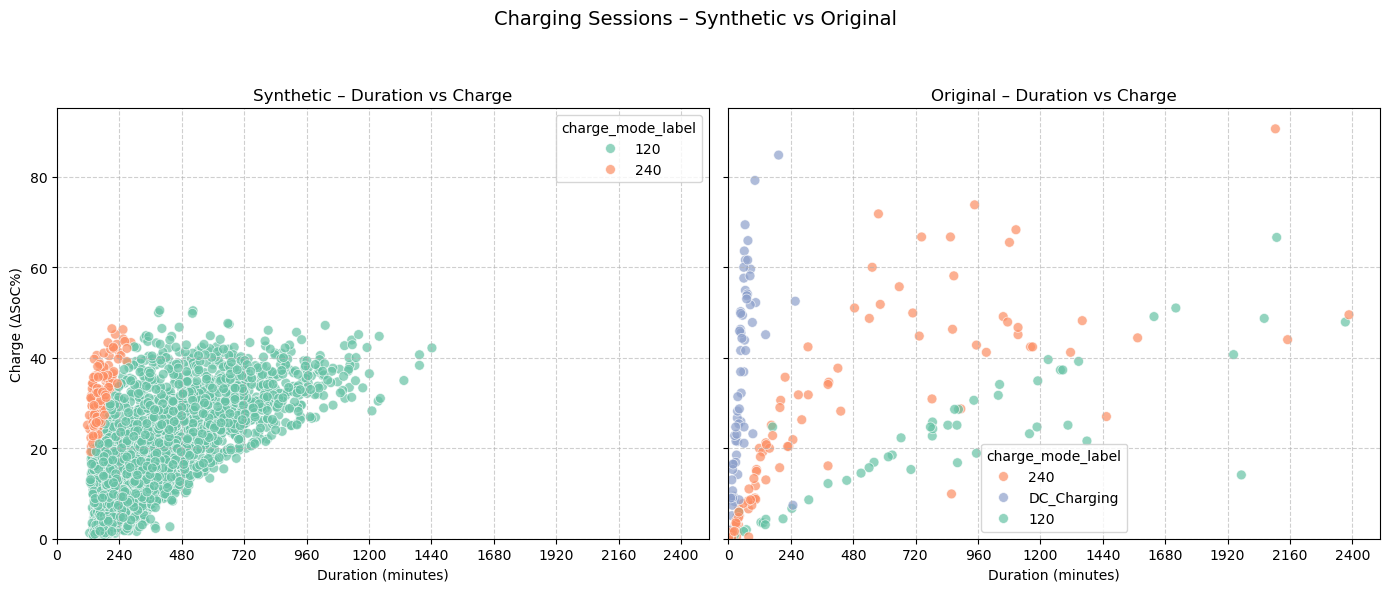

In [95]:
# --- Copy to avoid modifying originals ---
charge_data_syn = charge_data.copy()
charge_data_orig = charge_data_original.copy()

# --- Normalize charge_mode labels for consistency ---
def normalize_label_syn(val):
    if val == 1:
        return '120'
    elif val == 2:
        return '240'
    elif val == 3:
        return 'DC_Charging'
    else:
        return None

def normalize_label_orig(val):
    s = str(val).strip().lower()
    if 'dc' in s:
        return 'DC_Charging'
    elif '120' in s:
        return '120'
    elif '240' in s:
        return '240'
    else:
        return None

charge_data_syn['charge_mode_label'] = charge_data_syn['charge_mode'].apply(normalize_label_syn)
charge_data_orig['charge_mode_label'] = charge_data_orig['charge_mode'].apply(normalize_label_orig)

# --- Define consistent color palette ---
fixed_palette = {
    "120": "#66c2a5",        # greenish
    "240": "#fc8d62",        # orange
    "DC_Charging": "#8da0cb" # blue
}

# --- Shared axis limits for fair comparison ---
max_duration = max(
    charge_data_syn['duration_minutes'].max(),
    charge_data_orig['duration_minutes'].max()
)
max_charge = max(
    charge_data_syn['charge'].max(),
    charge_data_orig['charge'].max()
)

# --- Create side-by-side subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ==========================================================
# LEFT: Synthetic
# ==========================================================
sns.scatterplot(
    data=charge_data_syn,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Synthetic – Duration vs Charge", fontsize=12)
axes[0].set_xlim(0, max_duration * 1.05)
axes[0].set_ylim(0, max_charge * 1.05)
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Charge (ΔSoC%)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(60))

# ==========================================================
# RIGHT: Original
# ==========================================================
sns.scatterplot(
    data=charge_data_orig,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Original – Duration vs Charge", fontsize=12)
axes[1].set_xlim(0, max_duration * 1.05)
axes[1].set_ylim(0, max_charge * 1.05)
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(240))



# --- Final layout ---
fig.suptitle("Charging Sessions – Synthetic vs Original", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [96]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3161 entries, 0 to 3160
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    3161 non-null   int64  
 1   charge_mode              3161 non-null   int64  
 2   duration_minutes         3161 non-null   float64
 3   km_driven                3161 non-null   float64
 4   charge                   3161 non-null   float64
 5   id                       3161 non-null   int64  
 6   delta_soc                3161 non-null   float64
 7   min_per_perc_of_battery  3161 non-null   float64
 8   charge_per_min           3161 non-null   float64
 9   soc                      3161 non-null   int64  
 10  end_soc                  3161 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 271.8 KB


### Save charge data cleaned

In [97]:
if SAVE:
    # Save DataFrame
    charge_data.to_csv(file_charge_path_csv, index=False)

# Save cleaned dataset

In [98]:
if SAVE:
    # Take raw generated data
    data = synthetic_data.copy()
    
    # load also trip_data and charge_data and then filter data, keeping only rows present in trip_data and charge_data
    
    trip_data_cleaned = pd.read_csv(file_trip_path_csv) 
    
    #take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
    trip_data_cleaned = trip_data_cleaned[['id']]
    charge_data_cleaned = pd.read_csv(file_charge_path_csv)
    
    # take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
    charge_data_cleaned = charge_data_cleaned[[ 'id']]
    
    
    # keep rows that are present in ids of trip_data and charge_data
    data['id'] = data.index
    
    data = data[data['id'].isin(trip_data_cleaned['id']) | data['id'].isin(charge_data_cleaned['id'])]
    
    #drop columns 'id'
    data = data.drop(columns=['id'])
    
    #when event = 1 --> set end_odo = odo 
    #data.loc[data['event'] == 1, 'end_odo'] = data['odo']
    data.loc[data['event'] == 1, 'km_driven'] = 0
    
    # add in first position column 'vin', all rows with value -2.47174E+18 (vin2) or -1.12313E+18 (vin3)
    #data.insert(0, 'vin', -2.47174E+18)
    
    # map event 0 -> trip, 1 -> charge
    data['event'] = data['event'].map({0: 'trip', 1: 'charge'})
    
    # map charge_mode 1 -> 120, 2 -> 240, 3 -> DC Charging
    data['charge_mode'] = data['charge_mode'].map({0: 0, 1: 120, 2: 240, 3: 'DC Charging'})
    data.to_csv(file_cleaned_path_csv, index=False)

In [99]:
print(f'Retained {len(trip_data)} / {len(synthetic_data[synthetic_data['event'] == 0])} trip events')
print(f'Retained {len(charge_data)} / {len(synthetic_data[synthetic_data['event'] == 1])} charge events')
print(f'In summary the cleaned dataset is composed by {len(trip_data) + len(charge_data)} events, corresponding to {(len(trip_data) + len(charge_data)) * 100 / (len(synthetic_data[synthetic_data['event'] == 0]) + len(synthetic_data[synthetic_data['event'] == 1])):.2f}% of retained synthetic data.')

Retained 15725 / 23417 trip events
Retained 3161 / 3583 charge events
In summary the cleaned dataset is composed by 18886 events, corresponding to 69.95% of retained synthetic data.
